# Vehicle Type

What sort of vehicles are involved in these crashes? 

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib._color_data import BASE_COLORS, TABLEAU_COLORS, CSS4_COLORS, XKCD_COLORS

import os
os.chdir('..')
from scripts.crash_data_analysis import CrashDataAnalysis

In [2]:
df = pd.read_csv('data/crash_data_raw.csv', low_memory=False)

In [3]:
df.TU1_VEHICLE_TYPE.unique()

array(['SUV', 'Unknown (Hit and Run Only)', 'Pickup Truck/Utility Van',
       nan, 'Passenger Car/Passenger Van', 'UNDER INVESTIGATION',
       'Medium/Heavy Trucks GVWR/GCWR 16,001 and over',
       'Medium/Heavy Trucks GVWR/GCWR between 10,001 and 16,000',
       'Motorcycle', 'Other Vehicle Type (Describe in Narative)',
       'Working Vehicle/Equipment',
       'Non-School Bus (9 occupants or more including driver) in commerce',
       'Transit Bus', 'School Bus (all school buses)', 'Motor Home',
       'Autocycle', 'Low Speed Vehicle', 'Off Highway Vehicle/ATV',
       'Farm Equipment', 'OTHER', 'PASSENGER CAR/VAN',
       'HIT AND RUN UNKNOWN', 'PICKUP TRUCK/UTILITY VAN',
       'PICKUP TRUCK/UTILITY VAN WITH TRAILIER', 'VEHICLE OVER 10000 LBS',
       'MOTORCYCLE', 'BICYCLE', 'SUV WITH TRAILER',
       'PASSENGER CAR/VAN WITH TRAILER', 'MOTOR HOME', 'TRANSIT BUS',
       'NON-SCHOOL BUS', 'FARM EQUIPMENT', 'SCHOOL BUS', 'LIGHT RAIL',
       '  ', 'MOTORIZED BICYCLE', '0', 'UNK'

In [4]:
# df['at_fault_vehicle'] = df['TU1_VEHICLE_TYPE']

# otherize = ['  ', '0', 'UNK']
# for v in otherize:
#     df.loc[df.TU1_VEHICLE_TYPE == v, 'at_fault_vehicle'] = 'Other'

In [5]:
df['TU1_VEHICLE_TYPE_UPPER'] = df['TU1_VEHICLE_TYPE'].str.upper()

vehicle_type_mapping = {
    '  ': 'Other'
    , '0': 'Other'
    , 'UNK': 'Other'
    , 'OTHER VEHICLE TYPE (DESCRIBE IN NARATIVE)': 'Other'
    , 'OTHER': 'Other'
    , 'SUV WITH TRAILER': 'SUV'
    , 'PASSENGER CAR/VAN': 'Passenger Car/Van'
    , 'PASSENGER CAR/VAN WITH TRAILER': 'Passenger Car/Van'
    , 'PASSENGER CAR/PASSENGER VAN': 'Passenger Car/Van'
    , 'SCHOOL BUS': 'Bus'
    , 'SCHOOL BUS (ALL SCHOOL BUSES)': 'Bus'
    , 'TRANSIT BUS': 'Bus'
    , 'HIT AND RUN UNKNOWN': 'Unknown (Hit and Run Only)'
    , 'PICKUP TRUCK/UTILITY VAN': 'Pickup Truck'
    , 'PICKUP TRUCK/UTILITY VAN WITH TRAILIER': 'Pickup Truck'
    , 'VEHICLE OVER 10000 LBS': 'Semi Truck'
    , 'MOTORCYCLE': 'Motorcycle'
    , 'BICYCLE': 'Bicycle'
    , 'UNDER INVESTIGATION': 'Under Investigation'
    , 'NON-SCHOOL BUS': 'Bus'
    , 'NON-SCHOOL BUS (9 OCCUPANTS OR MORE INCLUDING DRIVER) IN COMMERCE': 'Bus'
    , 'MEDIUM/HEAVY TRUCKS GVWR/GCWR 16,001 AND OVER': 'Semi Truck'
    , 'MEDIUM/HEAVY TRUCKS GVWR/GCWR BETWEEN 10,001 AND 16,000': 'Semi Truck'
    , 'OFF HIGHWAY VEHICLE/ATV': 'Other'
    , 'MOTOR HOME': 'Other'
    , 'MOTORIZED BICYCLE': 'Motorcycle'
    , 'FARM EQUIPMENT': 'Other'
    , 'LOW SPEED VEHICLE': 'Other'
    , 'AUTOCYCLE': 'Motorcycle'
    , 'WORKING VEHICLE/EQUIPMENT': 'Other'
    , 'LIGHT RAIL': 'Other'
}

df['at_fault_vehicle'] = df['TU1_VEHICLE_TYPE_UPPER'].map(vehicle_type_mapping).fillna(df['TU1_VEHICLE_TYPE'])

In [16]:
df.groupby(['at_fault_vehicle', 'TU1_VEHICLE_TYPE_UPPER']).size()

at_fault_vehicle            TU1_VEHICLE_TYPE_UPPER                                           
Bicycle                     BICYCLE                                                               1129
Bus                         NON-SCHOOL BUS                                                         454
                            NON-SCHOOL BUS (9 OCCUPANTS OR MORE INCLUDING DRIVER) IN COMMERCE       90
                            SCHOOL BUS                                                             277
                            SCHOOL BUS (ALL SCHOOL BUSES)                                           68
                            TRANSIT BUS                                                           1139
Motorcycle                  AUTOCYCLE                                                               54
                            MOTORCYCLE                                                            1791
                            MOTORIZED BICYCLE                                     

In [6]:
df.groupby('TU1_VEHICLE_TYPE_UPPER').size()

TU1_VEHICLE_TYPE_UPPER
                                                                      2132
0                                                                        1
AUTOCYCLE                                                               54
BICYCLE                                                               1129
FARM EQUIPMENT                                                          28
HIT AND RUN UNKNOWN                                                  14703
LIGHT RAIL                                                              27
LOW SPEED VEHICLE                                                       26
MEDIUM/HEAVY TRUCKS GVWR/GCWR 16,001 AND OVER                         1121
MEDIUM/HEAVY TRUCKS GVWR/GCWR BETWEEN 10,001 AND 16,000                540
MOTOR HOME                                                             212
MOTORCYCLE                                                            1791
MOTORIZED BICYCLE                                                       92
NO

In [7]:
# If there are any all-caps values here, they need to be mapped to at_fault_vehicle
df.groupby('at_fault_vehicle').size().sort_values(ascending=False)

at_fault_vehicle
Passenger Car/Van             125653
SUV                            56511
Pickup Truck                   34482
Unknown (Hit and Run Only)     19647
Other                          10981
Semi Truck                      7985
Bus                             2028
Motorcycle                      1937
Under Investigation             1136
Bicycle                         1129
dtype: int64

In [8]:
# pd.pivot_table(
#     data=df
#     , values='one'
#     , index=['at_fault_vehicle', 'TU1_VEHICLE_TYPE_UPPER']
#     , columns='crash_year'
#     , aggfunc='sum'
#     , fill_value=0
# )

In [ ]:
df['one'] = 1
df['reported_date'] = pd.to_datetime(df['reported_date'], format='mixed')

In [9]:
at_fault_vehicle_pivot = pd.pivot_table(
    data=df
    , values='one'
    , index='at_fault_vehicle'
    , columns=df.reported_date.dt.year
    , aggfunc='sum'
    , fill_value=0
)

at_fault_vehicle_pivot.drop('Under Investigation', inplace=True)
at_fault_vehicle_pivot.sort_values(by=2025, ascending=False, inplace=True)
at_fault_vehicle_pivot

reported_date,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
at_fault_vehicle,,,,,,,,,,,,,
Passenger Car/Van,11237,11776,12655,12678,12829,12223,10734,6839,7767,7662,8350,7781,3122
SUV,3993,4636,5217,5330,5456,5573,5521,3739,4459,3830,3835,3554,1368
Pickup Truck,2745,2898,3179,3315,3298,3444,3091,2346,2576,2284,2294,2164,848
Unknown (Hit and Run Only),1550,1687,1682,1887,1792,1736,1745,1338,1567,1254,1322,1386,701
Semi Truck,642,722,742,806,760,841,865,543,553,462,491,402,156
Bus,202,209,196,220,222,239,199,90,89,104,92,106,60
Motorcycle,158,152,167,178,165,154,138,134,177,157,157,149,51
Other,915,870,806,885,1226,1202,2436,791,829,658,131,186,46
Bicycle,175,158,148,135,145,129,112,72,54,1,0,0,0


In [10]:
at_fault_vehicle_perc = at_fault_vehicle_pivot / at_fault_vehicle_pivot.sum(axis=0)

at_fault_vehicle_perc.style.format('{:.1%}').background_gradient(cmap='Reds')

reported_date,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
at_fault_vehicle,,,,,,,,,,,,,
Passenger Car/Van,52.0%,51.0%,51.0%,49.8%,49.5%,47.9%,43.2%,43.0%,43.0%,46.7%,50.1%,49.5%,49.1%
SUV,18.5%,20.1%,21.0%,21.0%,21.1%,21.8%,22.2%,23.5%,24.7%,23.3%,23.0%,22.6%,21.5%
Pickup Truck,12.7%,12.5%,12.8%,13.0%,12.7%,13.5%,12.4%,14.8%,14.3%,13.9%,13.8%,13.8%,13.4%
Unknown (Hit and Run Only),7.2%,7.3%,6.8%,7.4%,6.9%,6.8%,7.0%,8.4%,8.7%,7.6%,7.9%,8.8%,11.0%
Semi Truck,3.0%,3.1%,3.0%,3.2%,2.9%,3.3%,3.5%,3.4%,3.1%,2.8%,2.9%,2.6%,2.5%
Bus,0.9%,0.9%,0.8%,0.9%,0.9%,0.9%,0.8%,0.6%,0.5%,0.6%,0.6%,0.7%,0.9%
Motorcycle,0.7%,0.7%,0.7%,0.7%,0.6%,0.6%,0.6%,0.8%,1.0%,1.0%,0.9%,0.9%,0.8%
Other,4.2%,3.8%,3.3%,3.5%,4.7%,4.7%,9.8%,5.0%,4.6%,4.0%,0.8%,1.2%,0.7%
Bicycle,0.8%,0.7%,0.6%,0.5%,0.6%,0.5%,0.5%,0.5%,0.3%,0.0%,0.0%,0.0%,0.0%


In [20]:
known_at_fault_vehicle_pivot = pd.pivot_table(
    data=df
    , values='one'
    , index='at_fault_vehicle'
    , columns=df.reported_date.dt.year
    , aggfunc='sum'
    , fill_value=0
)

known_at_fault_vehicle_pivot.drop(['Under Investigation', 'Unknown (Hit and Run Only)', 'Other'], inplace=True)
known_at_fault_vehicle_pivot.sort_values(by=2025, ascending=False, inplace=True)

known_at_fault_vehicle_perc = known_at_fault_vehicle_pivot / known_at_fault_vehicle_pivot.sum(axis=0)

known_at_fault_vehicle_perc.style.format('{:.1%}').background_gradient(cmap='Blues')

reported_date,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
at_fault_vehicle,,,,,,,,,,,,,
Passenger Car/Van,58.7%,57.3%,56.7%,55.9%,56.1%,54.1%,52.0%,49.7%,49.6%,52.8%,54.9%,55.0%,55.7%
SUV,20.8%,22.6%,23.4%,23.5%,23.9%,24.7%,26.7%,27.2%,28.4%,26.4%,25.2%,25.1%,24.4%
Pickup Truck,14.3%,14.1%,14.3%,14.6%,14.4%,15.2%,15.0%,17.0%,16.4%,15.8%,15.1%,15.3%,15.1%
Semi Truck,3.4%,3.5%,3.3%,3.6%,3.3%,3.7%,4.2%,3.9%,3.5%,3.2%,3.2%,2.8%,2.8%
Bus,1.1%,1.0%,0.9%,1.0%,1.0%,1.1%,1.0%,0.7%,0.6%,0.7%,0.6%,0.7%,1.1%
Motorcycle,0.8%,0.7%,0.7%,0.8%,0.7%,0.7%,0.7%,1.0%,1.1%,1.1%,1.0%,1.1%,0.9%
Bicycle,0.9%,0.8%,0.7%,0.6%,0.6%,0.6%,0.5%,0.5%,0.3%,0.0%,0.0%,0.0%,0.0%


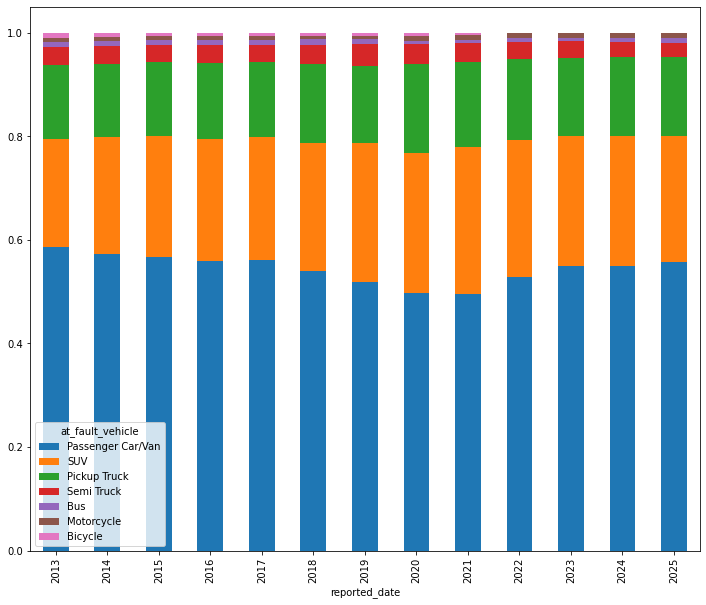

In [21]:
fig, ax = plt.subplots(figsize=(12,10))
_ = known_at_fault_vehicle_perc.transpose().plot(kind='bar', stacked=True, ax=ax)

## Conclusion

This data is now populating correctly in 2022 :)

In [12]:
df[df.incident_id == 2022165626].squeeze()

object_id                                               290681152
incident_id                                            2022165626
offense_id                                        202216562654410
offense_code                                                 5441
offense_code_extension                                          0
top_traffic_accident_offense       TRAF - ACCIDENT               
first_occurrence_date                         4/4/2022 3:00:00 PM
last_occurrence_date                          4/4/2022 3:00:00 PM
reported_date                                 2022-04-04 15:16:00
incident_address                        N GAYLORD ST / E 18TH AVE
geo_x                                                   3151566.0
geo_y                                                   1696624.0
geo_lon                                               -104.961005
geo_lat                                                 39.744803
district_id                                                6     
precinct_i

In [13]:
df.groupby('TU2_VEHICLE_TYPE').size().sort_values(ascending=False)

TU2_VEHICLE_TYPE
PASSENGER CAR/VAN                                                    97377
SUV                                                                  60793
Passenger Car/Passenger Van                                          30143
PICKUP TRUCK/UTILITY VAN                                             19363
OTHER                                                                16268
                                                                      8948
Pickup Truck/Utility Van                                              7189
VEHICLE OVER 10000 LBS                                                4630
PICKUP TRUCK/UTILITY VAN WITH TRAILIER                                3866
MOTORCYCLE                                                            1409
BICYCLE                                                               1319
TRANSIT BUS                                                           1229
UNDER INVESTIGATION                                                   1136
Medium/H